## Step 1: Creating Tokens

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


Our goal is to tokenize this 20,479-character short story into individual words and special
characters that we can then turn into embeddings for LLM training

Using some simple example text, we can use the re.split command with the following syntax to split a text on whitespace characters:

In [ ]:
import re

text = "Hello, world. This, is a test."
result = re.split(r'(\s)', text)

print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


Let's modify the regular expression splits on whitespaces (\s) and any kind of punctuations. Also, the list still includes whitespace characters. Optionally, we can remove these redundant characters safely as follows:

In [ ]:
text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()] #removes the whitespaces
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


Now that we got a basic tokenizer working, let's apply it to Edith Wharton's entire short
story:

In [ ]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [ ]:
print(len(preprocessed))

4690


## Step 2: Creating Token IDs

Each unique token is mapped to an unique integer called TokenID. So, now we need to create a list of all unique tokens and sort them alphabetically to determine the vocabulary size:

In [ ]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)

print(vocab_size)

1130


After determining that the vocabulary size is 1,130 via the above code, we create the vocabulary dictionary:

In [ ]:
vocab = {token:integer for integer,token in enumerate(all_words)}

the dictionary contains individual tokens associated with unique integer labels.

Let's implement a complete tokenizer class in Python.

The class will have an encode method that splits text into tokens and carries out the string-to-integer mapping to produce token IDs via the vocabulary.

In addition, we implement a decode method that carries out the reverse integer-to-string mapping to convert the token IDs back into text.

Step 1: Store the vocabulary as a class attribute for access in the encode and decode methods

Step 2: Create an inverse vocabulary that maps token IDs back to the original text tokens

Step 3: Process input text into token IDs

Step 4: Convert token IDs back into text

Step 5: Replace spaces before the specified punctuation

In [ ]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)

        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

### ADDING SPECIAL CONTEXT TOKENS

In the previous section, we implemented a simple tokenizer and applied it to a passage
from the training set.

In this section, we will modify this tokenizer to handle unknown
words.


In particular, we will modify the vocabulary and tokenizer we implemented in the
previous section, SimpleTokenizerV2, to support two new tokens, <|unk|> and
<|endoftext|>

Let's now modify the vocabulary to include these two special tokens, <unk> and
<|endoftext|>, by adding these to the list of all unique words that we created in the
previous section:

In [ ]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

vocab = {token:integer for integer,token in enumerate(all_tokens)}

Now we need to create a simple text tokenizer that handles unknown words

Step 1: Replace unknown words by <|unk|> tokens
    
Step 2: Replace spaces before the specified punctuations

In [ ]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [
            item if item in self.str_to_int
            else "<|unk|>" for item in preprocessed
        ]

        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text

In [ ]:
tokenizer = SimpleTokenizerV2(vocab)

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."

text = " <|endoftext|> ".join((text1, text2))

print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [ ]:
tokenizer.encode(text)

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]

In [ ]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.'

So far, we have discussed tokenization as an essential step in processing text as input to
LLMs. Depending on the LLM, some researchers also consider additional special tokens such
as the following:

[BOS] (beginning of sequence): This token marks the start of a text. It
signifies to the LLM where a piece of content begins.

[EOS] (end of sequence): This token is positioned at the end of a text,
and is especially useful when concatenating multiple unrelated texts,
similar to <|endoftext|>. For instance, when combining two different
Wikipedia articles or books, the [EOS] token indicates where one article
ends and the next one begins.

[PAD] (padding): When training LLMs with batch sizes larger than one,
the batch might contain texts of varying lengths. To ensure all texts have
the same length, the shorter texts are extended or "padded" using the
[PAD] token, up to the length of the longest text in the batch.

the tokenizer used for GPT models also doesn't use an <|unk|> token for outof-vocabulary words. Instead, GPT models use a byte pair encoding tokenizer, which breaks down words into subword units

### BYTE PAIR ENCODING (BPE)

We implemented a simple tokenization scheme in the previous sections for illustration
purposes.

This section covers a more sophisticated tokenization scheme based on a concept
called byte pair encoding (BPE).

The BPE tokenizer covered in this section was used to train
LLMs such as GPT-2, GPT-3, and the original model used in ChatGPT.
Since implementing BPE can be relatively complicated, we will use an existing Python open-source library called tiktoken

In [ ]:
! pip3 install tiktoken

In [ ]:
import importlib
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
text = ( "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
        "of someunknownPlace." )

integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


We can then convert the token IDs back into text using the decode method, similar to our SimpleTokenizerV2 earlier:

In [ ]:
strings = tokenizer.decode(integers)

print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


Second, the BPE tokenizer above encodes and decodes unknown words, such as
"someunknownPlace" correctly.

The BPE tokenizer can handle any unknown word. How does
it achieve this without using <|unk|> tokens?

The algorithm underlying BPE breaks down words that aren't in its predefined vocabulary into smaller subword units or even individual characters.

The enables it to handle out-ofvocabulary words.

So, thanks to the BPE algorithm, if the tokenizer encounters an unfamiliar word during tokenization, it can represent it as a sequence of subword tokens or characters

So, three advantages of Byte Pair Encoding (BPE):
1. the vocabulary size is not too high.
2. It retains the meaning of root words.
3. It automatically deals with unknown words!

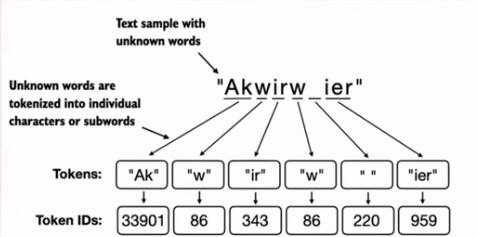

### CREATING INPUT-TARGET PAIRS

To get started, we will first tokenize the whole The Verdict short story we worked with earlier using the BPE tokenizer introduced in the previous section:

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [ ]:
context_size = 4

x = enc_text[:context_size]
y = enc_text[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

x: [40, 367, 2885, 1464]
y:      [367, 2885, 1464, 1807]


context size is used to specify the length of the input
The context_size of 4 means that the model is trained to look at a sequence of 4 words (or tokens)
to predict the next word in the sequence, The input x is the first 4 tokens [1, 2, 3, 4], and the target y is the next 4 tokens [2, 3, 4, 5]

In [ ]:
for i in range(1, context_size+1):
    context = enc_text[:i]
    desired = enc_text[i]

    print(context, "---->", desired)

[40] ----> 367
[40, 367] ----> 2885
[40, 367, 2885] ----> 1464
[40, 367, 2885, 1464] ----> 1807


Everything left of the arrow (---->) refers to the input an LLM would receive, and the token ID on the right side of the arrow represents the target token ID that the LLM is supposed to predict.

For illustration purposes, let's repeat the previous code but convert the token IDs into text:

In [ ]:
for i in range(1, context_size+1):
    context = enc_text[:i]
    desired = enc_text[i]

    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

I ---->  H
I H ----> AD
I HAD ---->  always
I HAD always ---->  thought


It looks like: 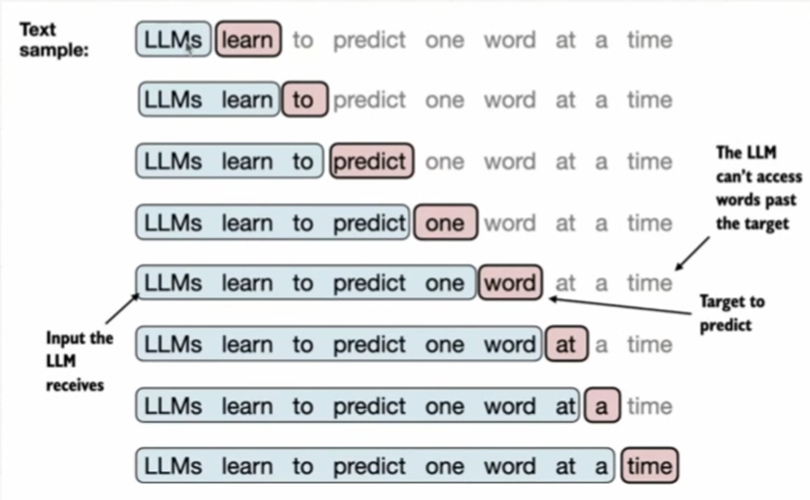

There's only one more task before we can turn the tokens into embeddings:implementing an efficient data loader that
iterates over the input dataset and returns the inputs and targets as PyTorch tensors, which
can be thought of as multidimensional arrays.

In particular, we are interested in returning two tensors: an input tensor containing the
text that the LLM sees and a target tensor that includes the targets for the LLM to predict,

### IMPLEMENTING A DATA LOADER

Step 1: Tokenize the entire text

Step 2: Use a sliding window to chunk the book into overlapping sequences of max_length

Step 3: Return the total number of rows in the dataset

Step 4: Return a single row from the dataset

We will implement a dataloader that fetches input-output target pairs using a sliding window approach.
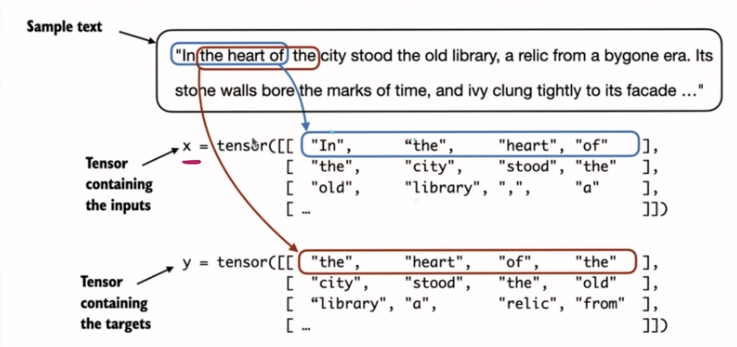

To implement efficient dataloaders, we collect inputs in a tensor x, where each row represents one input context. The second tensor y contains the corresponding prediction targets (next words), which are created by shifting input by one position.

In [ ]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

It defines how individual rows are fetched from the dataset.

Each row consists of a number of
token IDs (based on a max_length) assigned to an input_chunk tensor.

The target_chunk
tensor contains the corresponding targets.


About the stride: the stride means how many positions the input field will move.
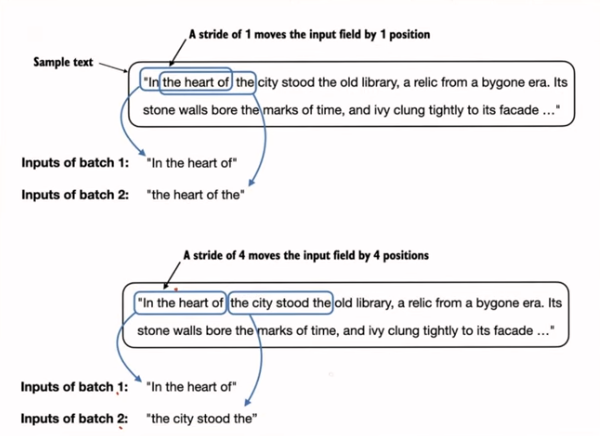

I recommend reading on to see how the data returned from this dataset looks like when we combine the dataset with a PyTorch DataLoader -- this will bring additional intuition and clarity.

Step 1: Initialize the tokenizer

Step 2: Create dataset

Step 3: drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes during training

Step 4: The number of CPU processes to use for preprocessing

In [ ]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size, #how many input batches do you want to process at one time before updating the parameters.
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

with open("the-verdict.txt", "r", encoding="utf-8") as f:


In [ ]:
import torch

dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


Before we move on to the two final sections of this chapter that are focused on creating the embedding vectors from the token IDs, let's have a brief look at how we can use the data loader to sample with a batch size greater than 1:

In [ ]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


Note that we increase the stride to 4. This is to utilize the data set fully (we don't skip a single word) but also avoid any overlap between the batches, since more overlap could lead to increased overfitting.

### CREATING TOKEN EMBEDDINGS

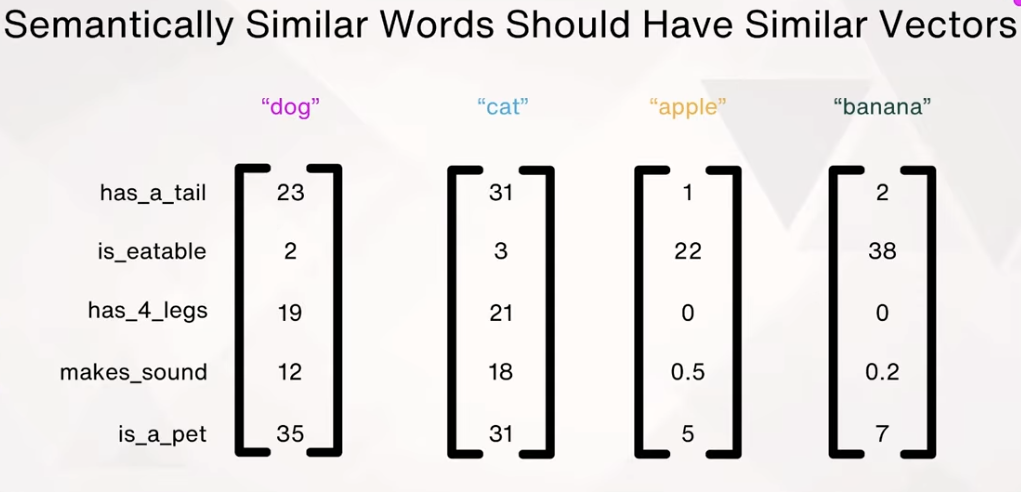

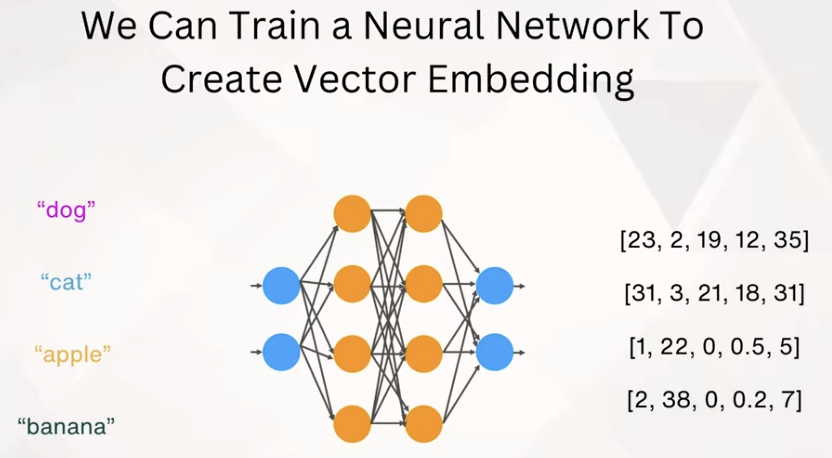

For LLM token embeddings are created by

a. Initialize embedding weuights with random values

b. This initialization serves as the starting point for the LLM learning process.

c. The embedding weights are optimized as part of the LLM training process.

d. need to sort the vocabulary alphabetically

Let's illustrate how the token ID to embedding vector conversion works with a hands-on example. Suppose we have the following four input tokens with IDs 2, 3, 5, and 1:

In [ ]:
input_ids = torch.tensor([2, 3, 5, 1])

For the sake of simplicity and illustration purposes, suppose we have a small vocabulary of only 6 words (instead of the 50,257 words in the BPE tokenizer vocabulary), and we want to create embeddings of size 3 (in GPT-3, the embedding size is 12,288 dimensions):

Using the vocab_size and output_dim, we can instantiate an embedding layer in PyTorch, setting the random seed to 123 for reproducibility purposes:

In [ ]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

with torch.nn.Embedding after specifying the number of embeddings and the embedding dimensions it creates a matrix with randomly assigned values.

Embedding Layer weight matrix is optimized during the training process.

The print statement in the code prints the embedding layer's underlying weight matrix:

In [ ]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


We can see that the weight matrix of the embedding layer contains small, random values. These values are optimized during LLM training as part of the LLM optimization itself, as we will see in upcoming chapters. Moreover, we can see that the weight matrix has six rows and three columns. There is one row for each of the six possible tokens in the vocabulary. And there is one column for each of the three embedding dimensions.



Previously, we have seen how to convert a single token ID into a three-dimensional embedding vector. Let's now apply that to all four input IDs we defined earlier (torch.tensor([2, 3, 5, 1])):

In [ ]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


Each row in this output matrix is obtained via a lookup operation from the embedding weight matrix. The embedding layer is a look up operation that retrieves rows from the embedding layer weight matrix using a token ID.

### POSITIONAL EMBEDDINGS (ENCODING WORD POSITIONS)

Previously, we focused on very small embedding sizes in this chapter for illustration
purposes.

We now consider more realistic and useful embedding sizes and encode the input
tokens into a 256-dimensional vector representation.

This is smaller than what the original
GPT-3 model used (in GPT-3, the embedding size is 12,288 dimensions) but still reasonable
for experimentation.

Furthermore, we assume that the token IDs were created by the BPE
tokenizer that we implemented earlier, which has a vocabulary size of 50,257:

In [ ]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

Using the token_embedding_layer above, if we sample data from the data loader, we embed each token in each batch into a 256-dimensional vector. If we have a batch size of 8 with four tokens each, the result will be an 8 x 4 x 256 tensor.

Let's instantiate the data loader ( Data sampling with a sliding window),
first:

In [ ]:
max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length, #each row of the input batch will have 4 token IDs (4 columns) and batch size = 8 so 8 rows will be there
    stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [ ]:
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


As we can see, the token ID tensor is 8x4-dimensional, meaning that the data batch consists of 8 text samples with 4 tokens each.

Let's now use the embedding layer to embed these token IDs into 256-dimensional vectors:

In [ ]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


As we can tell based on the 8x4x256-dimensional tensor output, each token ID is now embedded as a 256-dimensional vector. One embedding vector of 256 length is generated for each token in input.

For a GPT model's absolute embedding approach, we just need to create another embedding layer that has the same dimension as the token_embedding_layer:

In [ ]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

There are two types of Positional Embedding:
1. Absolute: For  each position in input sequence, a unique embedding is added to the tokens' embedding to convey its' exact location. The positional embedding vectors have the same dimension as the original token embeddings.

Suitable when foxed order of tokens is crucial, such as sequence generation.

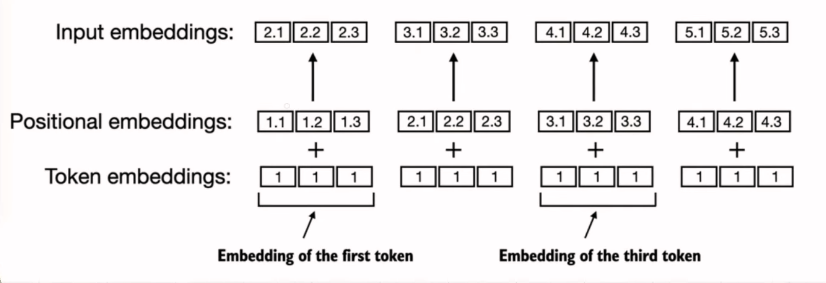

2. Relative: The emphasis is on the relative position on distance between tokens. The model learns the relationships in terms of "how far apart" rather than at which exact position. It has some advantage like: model can generalize better to sequence of varying lengths, even if it has not seen such lengths during training.

Suitable for tasks like language modeling over long sequences, where the same phrase can appear in different parts of the sequence.

In [ ]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length)) #Absolute Positional Encoding
print(pos_embeddings.shape)

torch.Size([4, 256])


As shown in the preceding code example, the input to the pos_embeddings is usually a placeholder vector torch.arange(context_length), which contains a sequence of numbers 0, 1, ..., up to the maximum input length − 1.

The context_length is a variable that represents the supported input size of the LLM.

Here, we choose it similar to the maximum length of the input text.

In practice, input text can be longer than the supported context length, in which case we have to truncate the text.



As we can see, the positional embedding tensor consists of four 256-dimensional vectors. We can now add these directly to the token embeddings, where PyTorch will add the 4x256- dimensional pos_embeddings tensor to each 4x256-dimensional token embedding tensor in each of the 8 batches:

In [ ]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


The input_embeddings we created are the embedded input examples that can now be processed by the main LLM modules